![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)

# Laboratory 4. Process Design Kit (PDK) and Layout

In [1]:
import gdsfactory as gf

## 1. Technology

We will work with the **demo UPVfab PDK**. (There are some other open-source PDKs, in other technologies, feel free to search if interested)

In [2]:
from upvfab.sin300.cband import PDK, cells

Let's view the layer distribution of this PDK. In our case, for the passive devices we will only use the **Layer 1**. 

2026-06-10 09:11:31.967 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


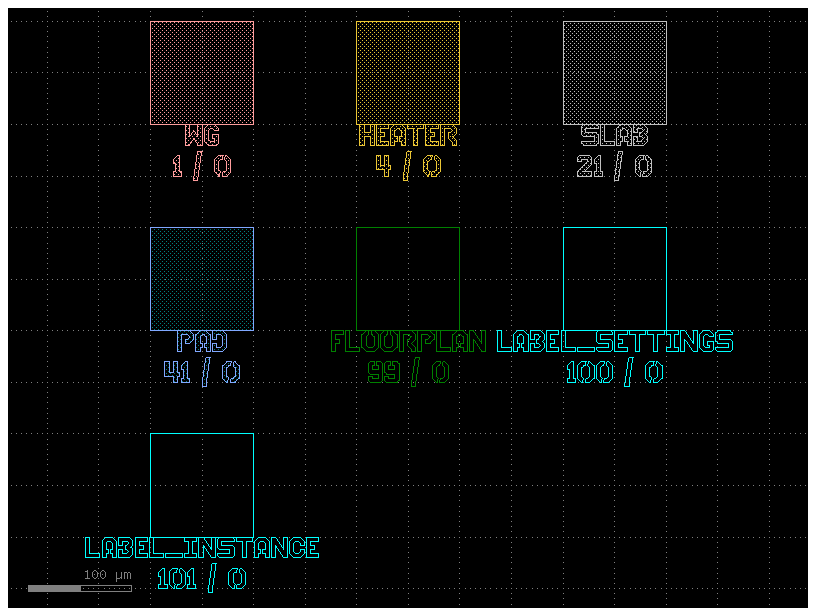

In [3]:
LAYER_VIEWS = PDK.layer_views
c = LAYER_VIEWS.preview_layerset()
c.show()
c.plot()

The new versions of GDS Factory allow to view the Layer Stack also (3D view of the fabrication flow). The following code allows to generate and view the Layer Stack of the generic PDK. Reference: https://www.degruyter.com/document/doi/10.1515/nanoph-2013-0034/html

The layers and the thicknesses have been defined previously on the PDK, so it is possible to view in 3D some of the components in the PDK. 

See the [Reference Manual](https://gdsfactory.github.io/gdsfactory/components.html) and read the list of the available components.

Here are some examples of the 3D views of this photonic components

2026-06-10 09:11:32.834 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


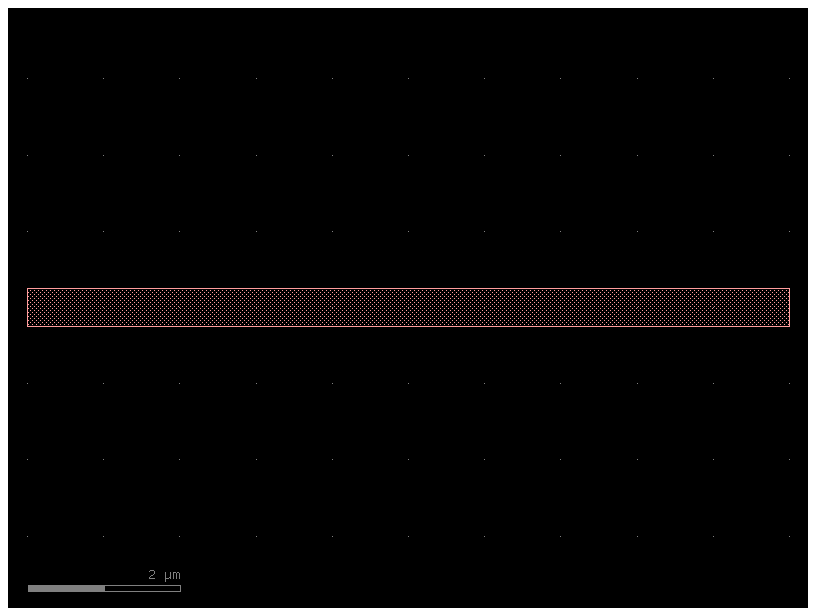

In [4]:
xs = gf.cross_section.strip(width=0.5, layer = 'WG')

c = gf.components.straight(length=10, cross_section=xs)  #Deep 
c.plot() # To view the component on Notebook
c.show() # To view on KLayout
scene = c.to_3d()
scene.show()


2026-06-10 09:11:33.385 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server
2026-06-10 09:11:33.469 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


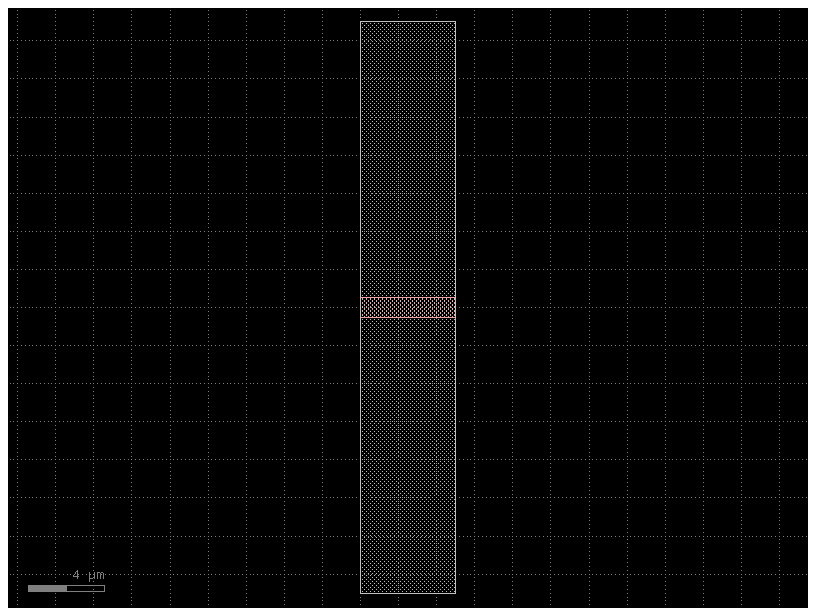

In [5]:
c = gf.components.straight(length=5, cross_section='rib') #Shallow
c.plot()
c.show()

scene = c.to_3d()
c.show()
scene.show()

2026-06-10 09:11:33.970 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


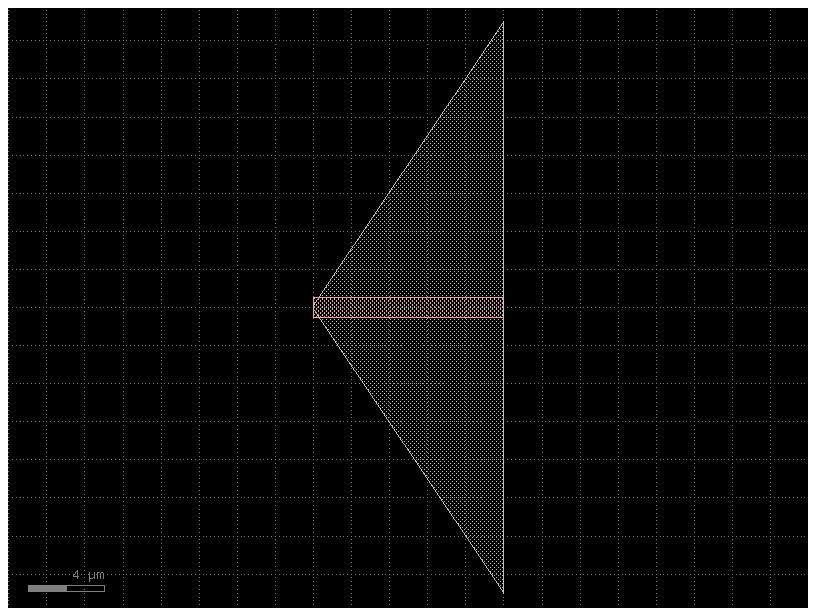

In [6]:
c = cells.taper_strip_to_ridge(length=10) #Taper
c.plot()
c.show()

scene = c.to_3d()
scene.show()

2026-06-10 09:11:34.586 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


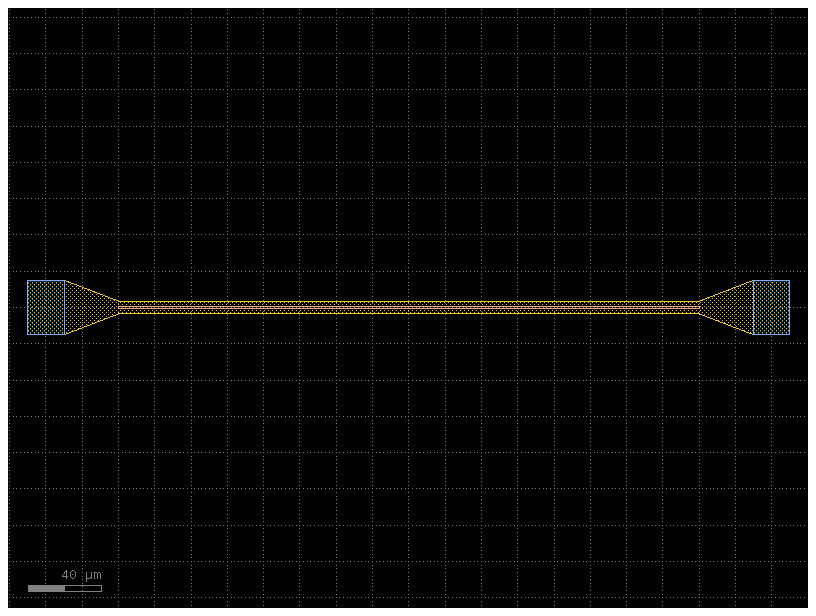

In [7]:
c = cells.straight_heater_metal()

#c.pprint_ports()

c.plot()
c.show()
#c.draw_ports()

scene = c.to_3d()
scene.show()

- Use your design results from Lab2 and Lab3 to create **layout** instances of your designed components: DCs, MMIs, MZIs & Ring Resonators. 

### 1.b.1. Directional Coupler

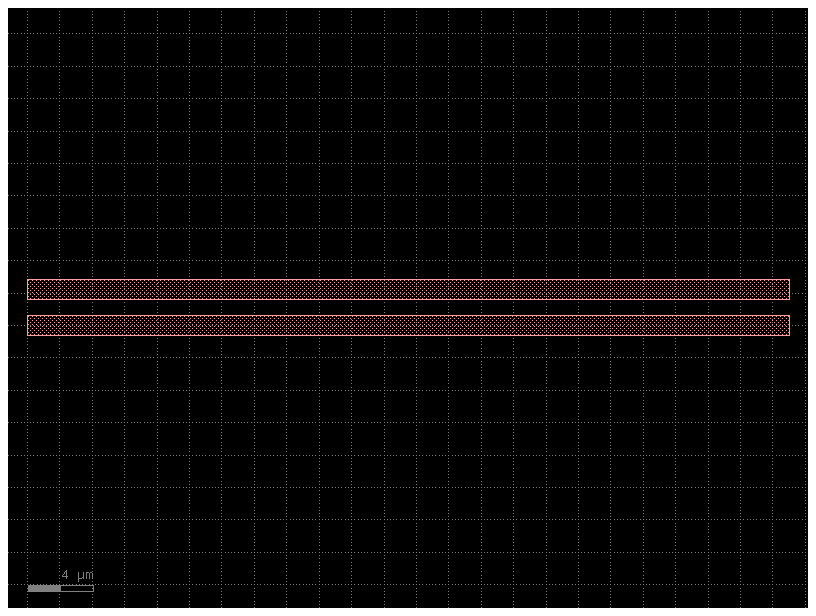

In [8]:
L = 94.027426/2
gap = 1  # 600 nm
width = 1.2
separation = width + gap  # distancia centro a centro

xs = gf.cross_section.strip(width=width, layer="WG")

# Crear componente
DC = gf.Component()

wg1 = DC.add_ref(gf.components.straight(length=L, cross_section=xs))
wg2 = DC.add_ref(gf.components.straight(length=L, cross_section=xs))

wg2.movey(separation)
DC.plot()

### 1.b.2. MMI

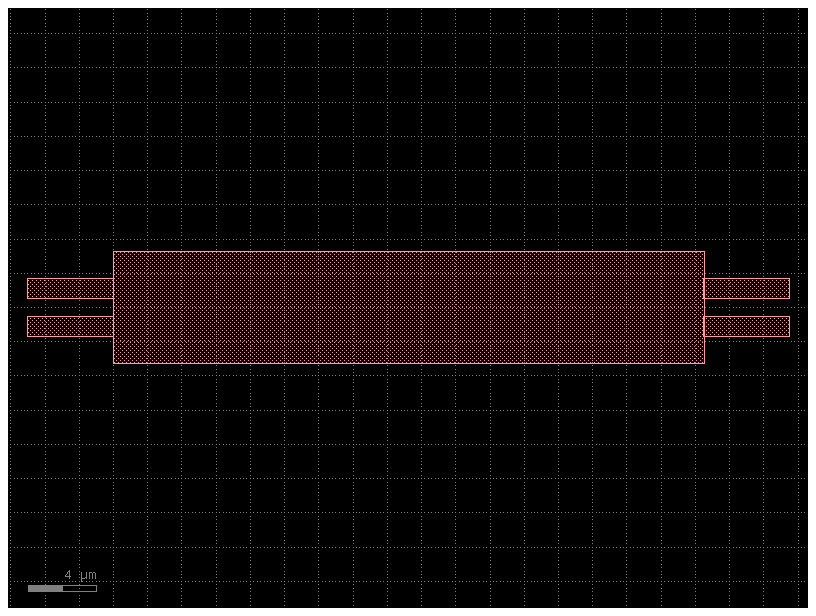

In [9]:
# Parámetros
w_wg = 1.2              # ancho de las guías en um
w_mmi = 6.6             # ancho de la región MMI en um
l_mmi = 69.03598/2      # longitud de la región MMI en um
l_wg = 5.0              # longitud de guías de acceso
gap_out = 1.5           # separación entre salidas centro-centro

xs = gf.cross_section.strip(width=w_wg, layer="WG")
mmi = gf.Component()

# Región MMI
MMI = mmi.add_ref(gf.components.rectangle(size=(l_mmi, w_mmi),layer="WG"))

# Centrar MMI en y = 0
MMI.dcenter = (l_mmi / 2, 0)

# Guías
wg1 = mmi.add_ref(gf.components.straight(length=l_wg, cross_section=xs)).dmovex(-l_wg).dmovey(w_mmi/6)
wg2 = mmi.add_ref(gf.components.straight(length=l_wg, cross_section=xs)).dmovex(-l_wg).dmovey(-w_mmi/6)

wg3 = mmi.add_ref(gf.components.straight(length=l_wg, cross_section=xs)).dmovex(l_mmi).dmovey(w_mmi/6)
wg4 = mmi.add_ref(gf.components.straight(length=l_wg, cross_section=xs)).dmovex(l_mmi).dmovey(-w_mmi/6)

mmi.plot()

### 1.b.3. MZI

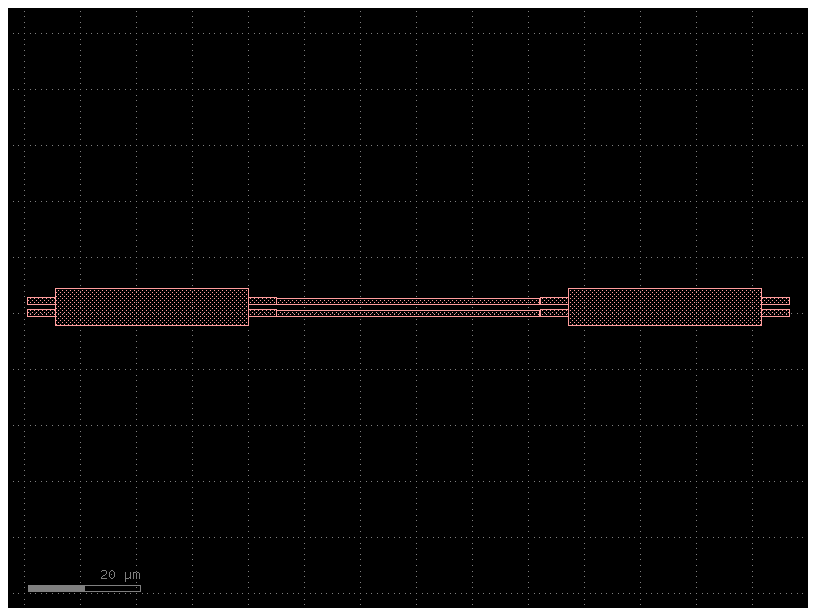

In [10]:
mzi = gf.Component()
dc = mzi.add_ref(DC).dmovex(l_wg)
MMI_1 = mzi.add_ref(mmi).dmovex(-l_mmi).dmovey(w_mmi/6)
MMI_2 = mzi.add_ref(mmi).dmovex(2*l_wg+47.013713).dmovey(w_mmi/6)
mzi.plot()

### 1.b.4. Ring Resonator

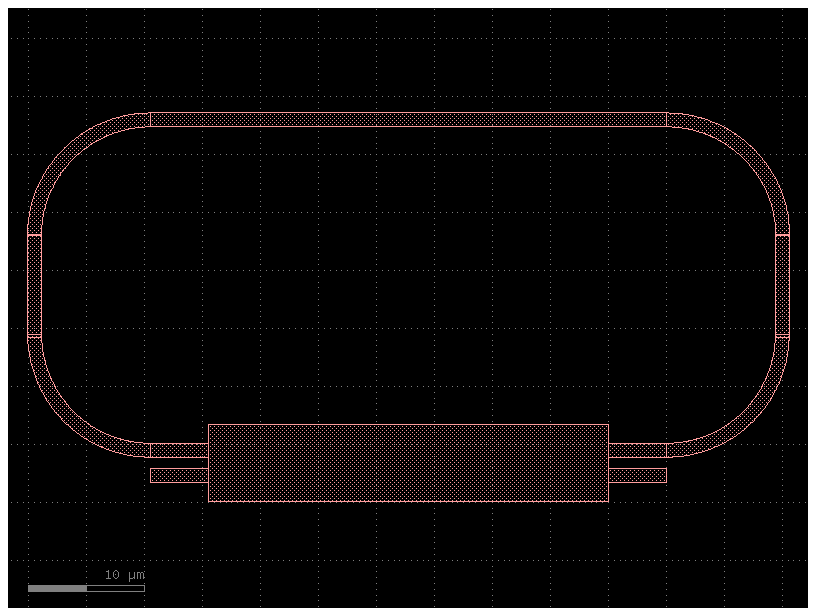

In [11]:
# Parámetros
w_wg = 1.2              # ancho de las guías en um
w_mmi = 6.6             # ancho de la región MMI en um
l_mmi = 69.03598/2      # longitud de la región MMI en um
l_wg = 5.0              # longitud de guías de acceso
gap_out = 1.5           # separación entre salidas centro-centro

L = l_mmi + 2*l_wg

RR = gf.Component()
MMI_RR = RR.add_ref(mmi).dmovex(-l_mmi).dmovey(-w_mmi)
wg_RR1 = RR.add_ref(gf.components.straight(length=L, cross_section=xs)).dmovex(-l_mmi-l_wg).dmovey(23)
wg_RR2 = RR.add_ref(gf.components.straight(length=L/5, cross_section=xs)).dmovex(4.2).dmovey(l_mmi+3*l_wg).rotate(90)
wg_RR3 = RR.add_ref(gf.components.straight(length=L/5, cross_section=xs)).dmovex(4.2).dmovey(-l_mmi+4*l_wg-0.5).rotate(90)

# Crear los codos de 90° para las 4 esquinas
bend = gf.components.bend_euler(angle=90, p=0, cross_section=xs)

# Esquina superior derecha
bend1 = RR.add_ref(bend)
bend1.dmovex(13).dmovey(-l_mmi+4*l_wg-0.5).rotate(90)  # rotación según la orientación

# Esquina superior izquierda
bend3 = RR.add_ref(bend)
bend3.dmovex(l_mmi+l_wg).dmovey(-23).rotate(180)

# Esquina inferior izquierda
bend3 = RR.add_ref(bend)
bend3.dmovex(-4.5).dmovey(-l_mmi-3*l_wg).rotate(270)

# Esquina inferior derecha
bend3 = RR.add_ref(bend)
bend3.dmovex(l_wg).dmovey(-5.5).rotate(360)

RR.plot()

## 2. Layout Fundamentals

A cell is a function that returns a Component. In GDS each component must have a unique name. Two components stored in the GDS file cannot have the same name. They need to be references (instances) of the same component.

![GDSFactoryComponents][def]


[def]: https://i.imgur.com/oeuKGsc.png

2026-06-10 09:11:36.511 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


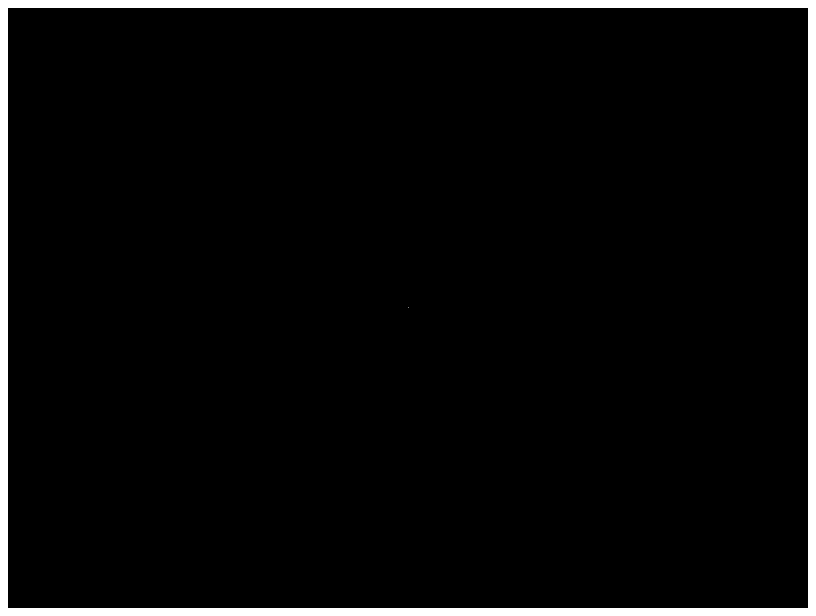

In [12]:
c = gf.Component()
c.plot()
c.show()

Let's build a Component from scratch. A die (chip) for a photonic layout. The PDK or Design Manual should specify the Layer for the bounding box (dicing line). 
We should also consider: 
1. The die dimensions and 
2. The border for dicing 

2026-06-10 09:11:36.807 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


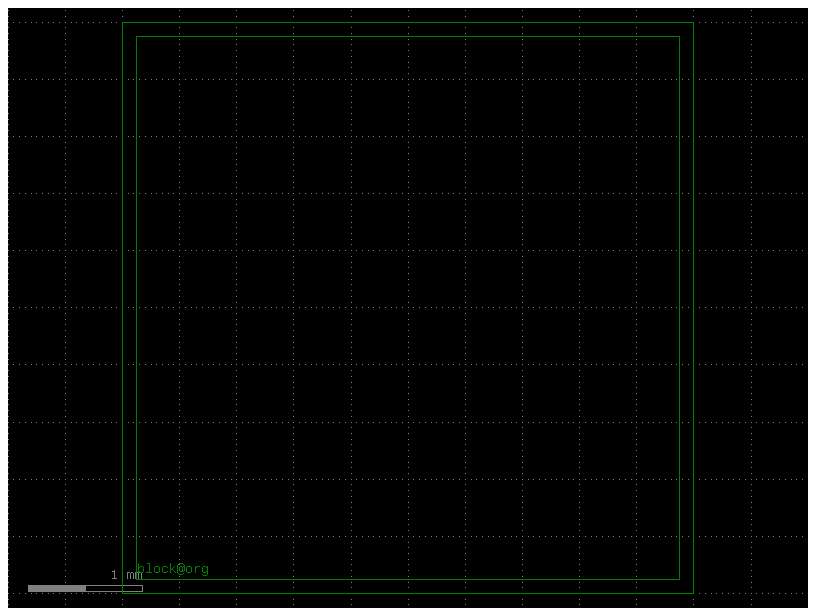

In [13]:
wgw = 0.5
dieL = 5000
dieW = 5000
border = 125
layer_wg = "WG"
layer_box = "FLOORPLAN"

# Die specifications (Chip)
box = gf.Component()

obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
box = gf.boolean(A=obox, B=ibox, operation="A-B", layer="FLOORPLAN")

# Adding ports to a component 
box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)

box.draw_ports()
box.show()
box.plot()

### Mantra: 
Once that we have a working 'new' component, we shall convert it into a Cell. This will allow us to have a hierarchical design

2026-06-10 09:11:37.310 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


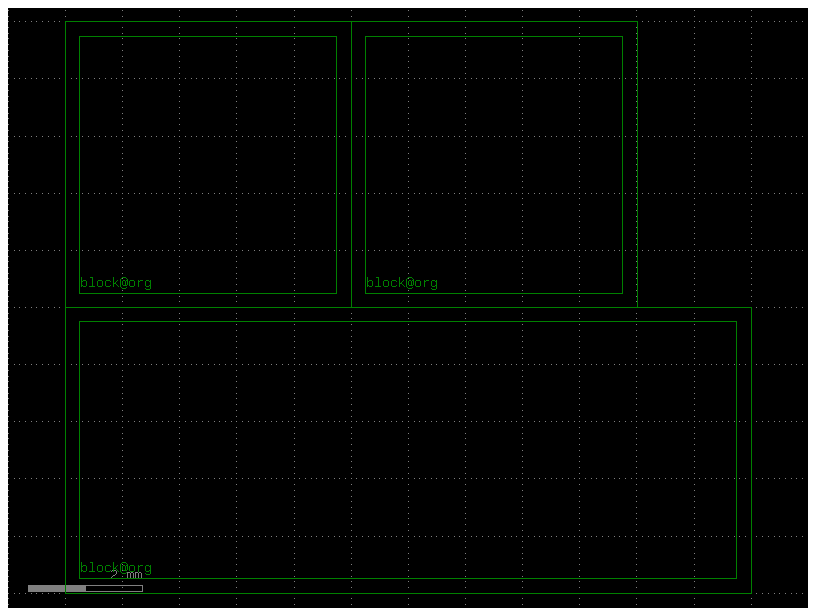

In [14]:
# 1. We define the cell as a function with it's corresponding parameters (and defaults)
gf.clear_cache()

@gf.cell
def die(dieL = 5000, dieW = 5000, border = 250, layer_box = "FLOORPLAN"):
    # Die specifications (Chip)
    box = gf.Component()
    obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
    box = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    # Adding ports to a component 
    box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)
    box.draw_ports()
    return box

# 2. We instantiate references of each cell. We can also name it individually to avoid problems
wafer = gf.Component()
dieW1 = 5000
dieW2 = 10000

c1 = wafer.add_ref(die(dieW = dieW))
c2 = wafer.add_ref(die(dieW = dieW))
c3 = wafer.add_ref(die(dieW = 12000))

c2.dmovex(dieW1)
c3.dmovey(-5000)
wafer.show()
wafer.plot()


### 2.b.1. Cell of Directional Coupler

2026-06-10 09:11:38.029 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


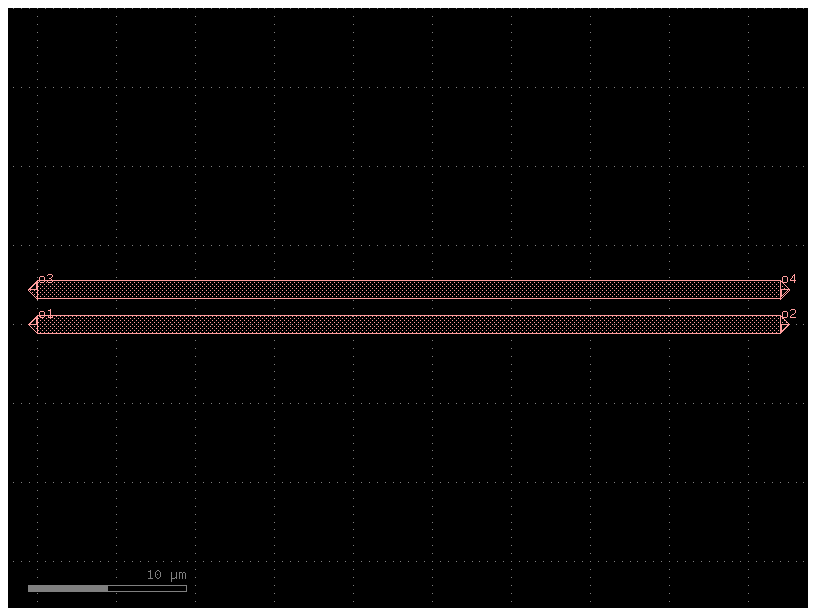

In [15]:
@gf.cell
def directional_coupler_cell(L=94.027426/2,gap=1.0,width=1.2,layer_wg="WG",):
    
    separation = width + gap
    xs = gf.cross_section.strip(width=width, layer=layer_wg)

    c = gf.Component()

    wg1 = c.add_ref(gf.components.straight(length=L,cross_section=xs))
    wg2 = c.add_ref(gf.components.straight(length=L,cross_section=xs))
    wg2.dmovey(separation)

    c.add_port("o1", port=wg1.ports["o1"])
    c.add_port("o2", port=wg1.ports["o2"])
    c.add_port("o3", port=wg2.ports["o1"])
    c.add_port("o4", port=wg2.ports["o2"])
    
    c.draw_ports()

    return c

dc = directional_coupler_cell()
dc.plot()
dc.show()

### 2.b.2. Cell of MMI

2026-06-10 09:11:38.472 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


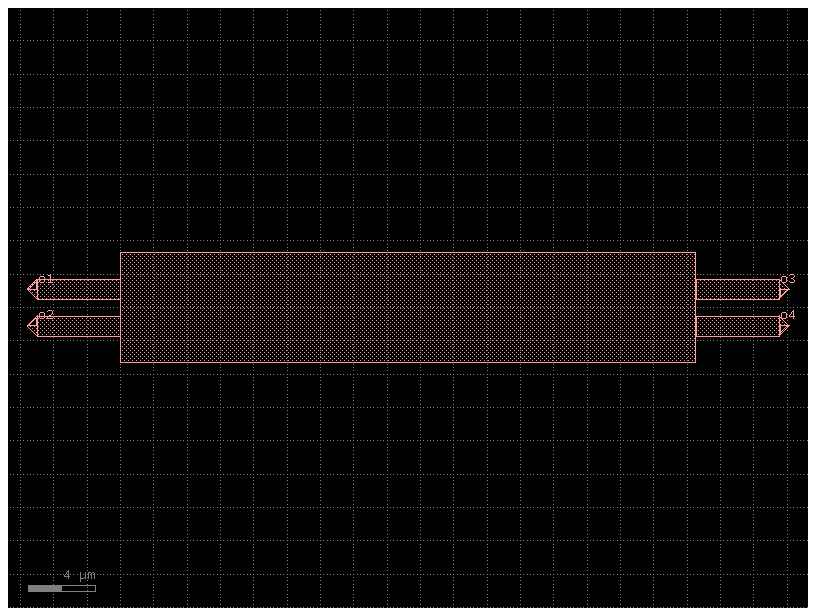

In [16]:
@gf.cell
def mmi_cell(w_wg=1.2,w_mmi=6.6,l_mmi=69.03598/2,l_wg=5,layer_wg="WG",):
    
    xs = gf.cross_section.strip(width=w_wg, layer=layer_wg)
    c = gf.Component()

    mmi = c.add_ref(gf.components.rectangle(size=(l_mmi, w_mmi),layer=layer_wg))
    mmi.dcenter = (l_mmi / 2, 0)

    wg1 = c.add_ref(gf.components.straight(length=l_wg,cross_section=xs)).dmovex(-l_wg).dmovey(w_mmi / 6)
    wg2 = c.add_ref(gf.components.straight(length=l_wg,cross_section=xs)).dmovex(-l_wg).dmovey(-w_mmi / 6)

    wg3 = c.add_ref(gf.components.straight(length=l_wg,cross_section=xs)).dmovex(l_mmi).dmovey(w_mmi / 6)
    wg4 = c.add_ref(gf.components.straight(length=l_wg,cross_section=xs)).dmovex(l_mmi).dmovey(-w_mmi / 6)

    c.add_port("o1", port=wg1.ports["o1"])
    c.add_port("o2", port=wg2.ports["o1"])
    c.add_port("o3", port=wg3.ports["o2"])
    c.add_port("o4", port=wg4.ports["o2"])

    c.draw_ports()

    return c

mmi = mmi_cell()
mmi.plot()
mmi.show()

### 2.b.3. Cell of MZI

2026-06-10 09:11:38.966 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


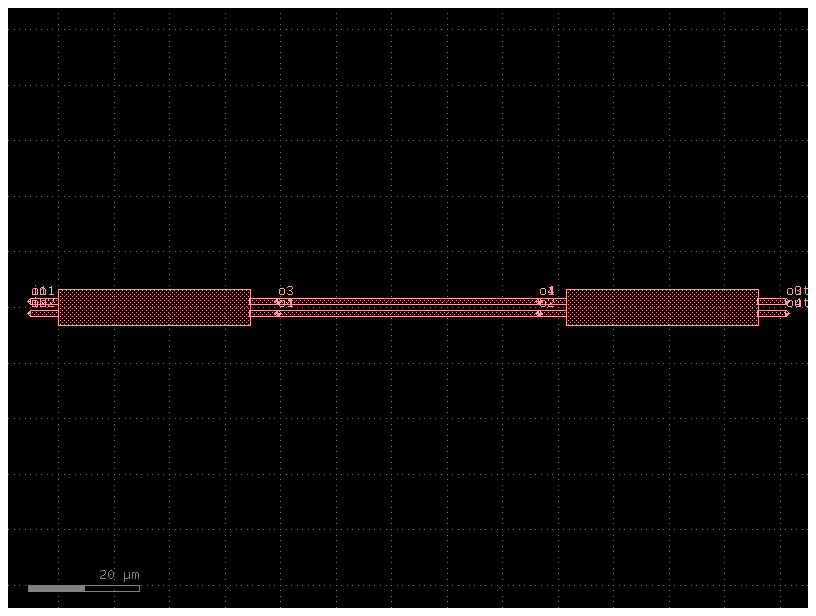

In [17]:
@gf.cell
def mzi_cell_2b3(w_wg=1.2,w_mmi=6.6,l_mmi=69.03598/2,l_wg=5.0,dc_length=94.027426/2,layer_wg="WG",):
    c = gf.Component()

    separation_mmi = 2 * (w_mmi / 6)
    gap_dc = separation_mmi - w_wg

    mmi1_ref = c.add_ref(mmi_cell(w_wg=w_wg,w_mmi=w_mmi,l_mmi=l_mmi,l_wg=l_wg,layer_wg=layer_wg,))
    dc_ref = c.add_ref(directional_coupler_cell(L=dc_length,gap=gap_dc,width=w_wg,layer_wg=layer_wg,))
    mmi2_ref = c.add_ref(mmi_cell(w_wg=w_wg,w_mmi=w_mmi,l_mmi=l_mmi,l_wg=l_wg,layer_wg=layer_wg,))


    dc_ref.dmovex(l_mmi + l_wg)
    dc_ref.dmovey(-w_mmi / 6)
    mmi2_ref.dmovex(l_mmi + 2*l_wg + dc_length)

    c.add_port("in1", port=mmi1_ref.ports["o1"])
    c.add_port("in2", port=mmi1_ref.ports["o2"])
    c.add_port("out1", port=mmi2_ref.ports["o3"])
    c.add_port("out2", port=mmi2_ref.ports["o4"])
    
    c.draw_ports()

    return c

mzi = mzi_cell_2b3()
mzi.plot()
mzi.show()

### 2.b.4. Cell of Ring Resonator

2026-06-10 09:11:39.460 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


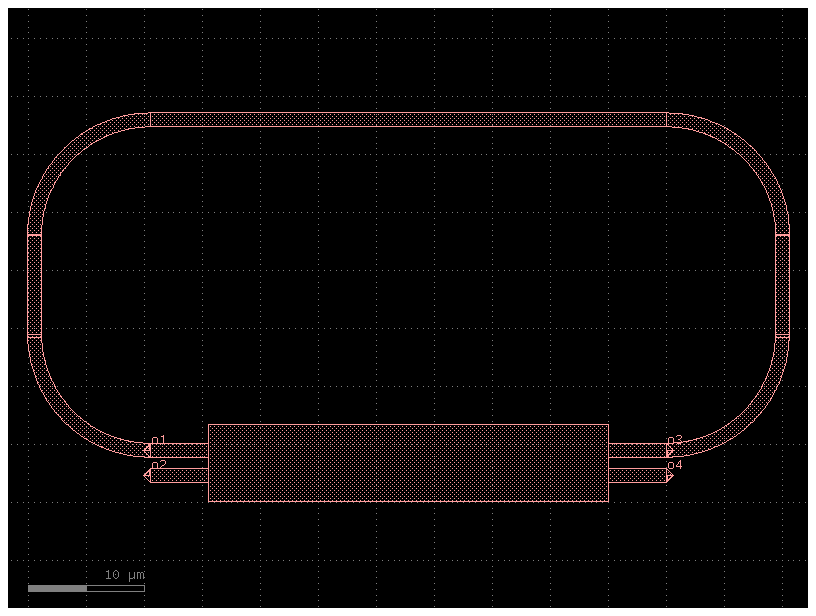

In [18]:
@gf.cell
def ring_resonator_cell(w_wg=1.2,w_mmi=6.6,l_mmi=69.03598/2,l_wg=5.0,layer_wg="WG",):
    c = gf.Component()
    xs = gf.cross_section.strip(width=w_wg, layer=layer_wg)
    L = l_mmi + 2*l_wg

    MMI_RR = c.add_ref(mmi_cell(w_wg=w_wg,w_mmi=w_mmi,l_mmi=l_mmi,l_wg=l_wg,layer_wg=layer_wg,))
    MMI_RR.dmovex(-l_mmi)
    MMI_RR.dmovey(-w_mmi)

    wg_RR1 = c.add_ref(gf.components.straight(length=L,cross_section=xs))
    wg_RR1.dmovex(-l_mmi - l_wg)
    wg_RR1.dmovey(23)

    wg_RR2 = c.add_ref(gf.components.straight(length=L/5,cross_section=xs))
    wg_RR2.dmovex(4.2)
    wg_RR2.dmovey(l_mmi + 3*l_wg)
    wg_RR2.rotate(90)

    wg_RR3 = c.add_ref(gf.components.straight(length=L/5,cross_section=xs))
    wg_RR3.dmovex(4.2)
    wg_RR3.dmovey(-l_mmi + 4*l_wg - 0.5)
    wg_RR3.rotate(90)

    bend = gf.components.bend_euler(angle=90,p=0,cross_section=xs)

    bend1 = c.add_ref(bend)
    bend1.dmovex(13)
    bend1.dmovey(-l_mmi + 4*l_wg - 0.5)
    bend1.rotate(90)

    bend2 = c.add_ref(bend)
    bend2.dmovex(l_mmi + l_wg)
    bend2.dmovey(-23)
    bend2.rotate(180)

    bend3 = c.add_ref(bend)
    bend3.dmovex(-4.5)
    bend3.dmovey(-l_mmi - 3*l_wg)
    bend3.rotate(270)

    bend4 = c.add_ref(bend)
    bend4.dmovex(l_wg)
    bend4.dmovey(-5.5)
    bend4.rotate(360)

    c.add_port("in1", port=MMI_RR.ports["o1"])
    c.add_port("in2", port=MMI_RR.ports["o2"])
    c.add_port("out1", port=MMI_RR.ports["o3"])
    c.add_port("out2", port=MMI_RR.ports["o4"])

    return c

ring = ring_resonator_cell()
ring.plot()
ring.show()

## 3. Complete Layout

2026-06-10 09:11:39.876 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


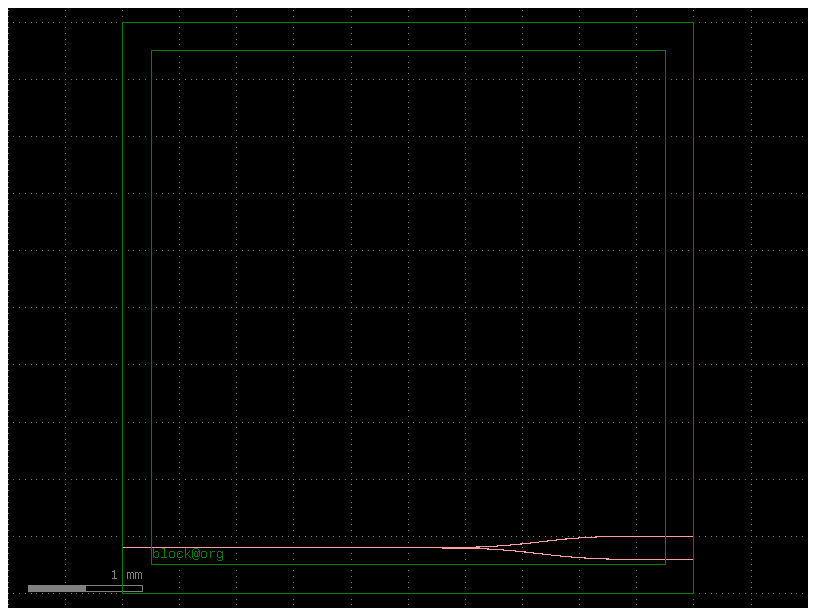

In [19]:
layer_wg  = "WG"
minrad = 50
dieW = 5000

main = gf.Component()

die_ref = main.add_ref(die(dieW = dieW, layer_box="FLOORPLAN"))

c_mmi = cells.mmi1x2()
mmi = main.add_ref(c_mmi)
mmi.dmovex(die_ref["block@org"].dx + 0.5*dieW).dmovey(die_ref['block@org'].dy + 150)

xs = 'strip'

strin = (main.add_ref(gf.components.straight(length=500, cross_section='strip')).dmovex(0).dmovey(mmi['o1'].dy))
strout1 = (main.add_ref(gf.components.straight(length=500, cross_section=xs)).drotate(180).dmovey(mmi.ports['o3'].dy-100).dmovex(dieW))
strout2 = (main.add_ref(gf.components.straight(length=500, cross_section=xs)).drotate(180).dmovey(mmi.ports['o2'].dy+100).dmovex(dieW))

gf.routing.route_single_sbend(main,port1=strin['o2'], port2=mmi['o1'], cross_section=xs)
gf.routing.route_single_sbend(main,port1=mmi['o2'], port2=strout2['o2'], cross_section=xs)
gf.routing.route_single_sbend(main,port1=mmi['o3'], port2=strout1['o2'], cross_section=xs)

main.plot()
main.show()

2026-06-10 09:11:40.242 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


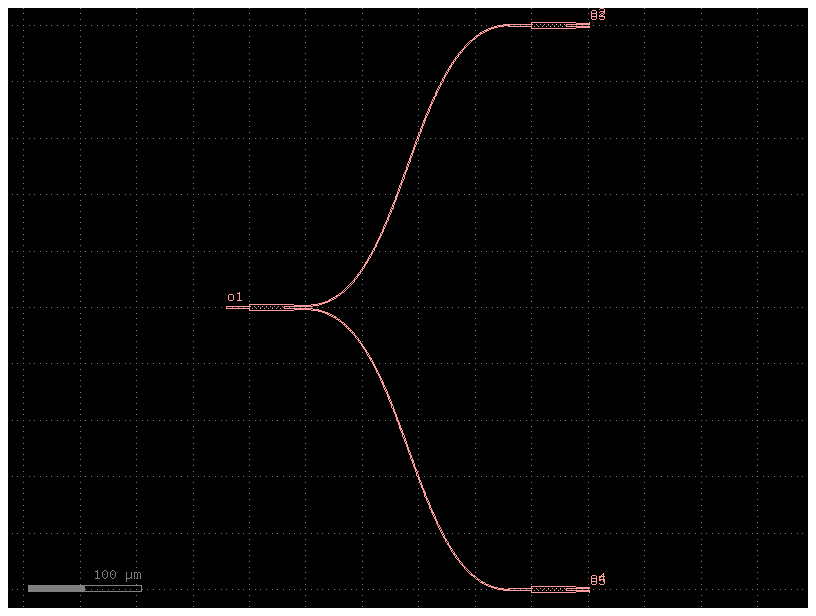

In [20]:
c = gf.Component()

c_mmi = cells.mmi1x2()

mmi1 = c.add_ref(c_mmi)
mmi2 = c.add_ref(c_mmi)
mmi3 = c.add_ref(c_mmi)

pad_x = 250
pad_y = 250

mmi2.dmovex(pad_x).dmovey(pad_y)
mmi3.dmovex(pad_x).dmovey(-pad_y)

gf.routing.route_single_sbend(
    component=c,
    port1=mmi1["o2"],
    port2=mmi2["o1"],
    cross_section="strip"
)

gf.routing.route_single_sbend(
    component=c,
    port1=mmi1["o3"],
    port2=mmi3["o1"],
    cross_section="strip"
)

c.add_port(name="o1", port=mmi1["o1"])
c.add_port(name="o2", port=mmi2["o2"])
c.add_port(name="o3", port=mmi2["o3"])
c.add_port(name="o4", port=mmi3["o2"])
c.add_port(name="o5", port=mmi3["o3"])

c.draw_ports()

c.plot()
c.show()

In [21]:
@gf.cell 
def mmi_tree_1x4(pad_x = 250 ,pad_y = 250):
    c = gf.Component()
    c_mmi = cells.mmi1x2()
    mmi1 = c.add_ref(c_mmi)
    mmi2 = c.add_ref(c_mmi)
    mmi3 = c.add_ref(c_mmi)

    mmi2.dmovex(pad_x).dmovey(pad_y)
    mmi3.dmovex(pad_x).dmovey(-pad_y)

    gf.routing.route_single_sbend(component=c, port1= mmi1['o2'], port2=mmi2['o1'],cross_section='strip')
    gf.routing.route_single_sbend(component=c, port1= mmi1['o3'], port2=mmi3['o1'],cross_section='strip')
    c.add_port(name='o1', port=mmi1['o1'])
    c.add_port(name='o2', port=mmi2['o2'])
    c.add_port(name='o3', port=mmi2['o3'])
    c.add_port(name='o4', port=mmi3['o2'])
    c.add_port(name='o5', port=mmi3['o3'])
    c.draw_ports()
    return c

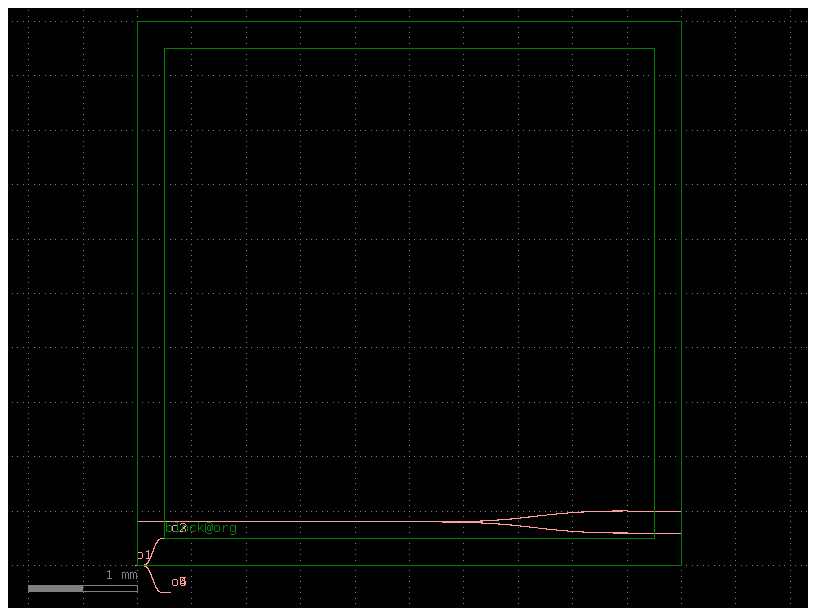

In [22]:
cell_1x4 = main.add_ref(mmi_tree_1x4())
main.plot()

2026-06-10 09:11:41.097 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


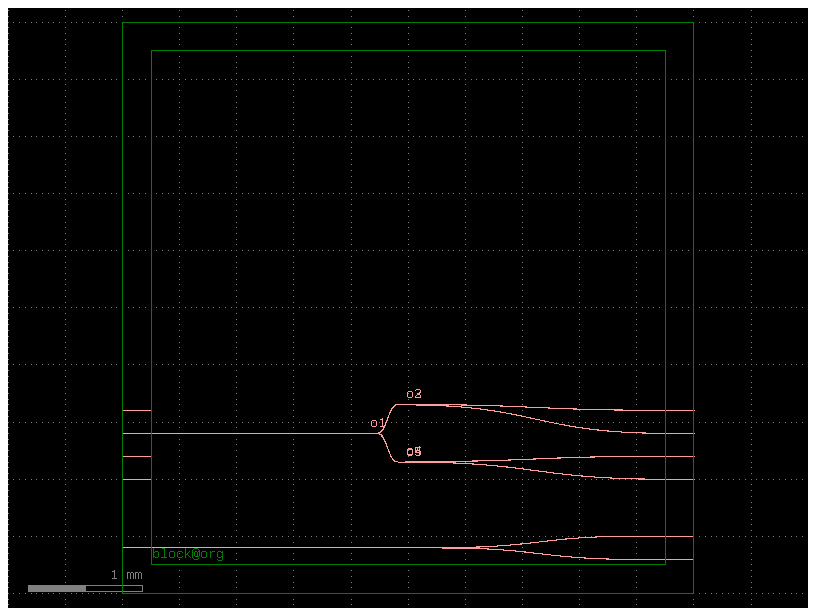

In [23]:
sp = 200
border = 250

in_arr = main.add_ref(
    gf.components.straight_array(n=4, spacing=sp, length=border, cross_section=xs)
).dmovey(
    1000
)

out_arr = (
    main.add_ref(
        gf.components.straight_array(n=4, spacing=sp, length=border, cross_section=xs)
    )
    .dmovex(dieW - border)
    .dmovey(1000)
)

cell_1x4.dmovex(0.5*dieW - mmi_tree_1x4().dxsize).dmovey(in_arr['o6'].dy)
gf.routing.route_single_sbend(component=main, port1=in_arr['o6'], port2=cell_1x4['o1'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o2'], port2=out_arr['o4'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o3'], port2=out_arr['o3'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o4'], port2=out_arr['o2'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o5'], port2=out_arr['o1'])
main.plot()
main.show()

### Mantra:
It's useful to use memorize this mantra: 
- Add_references 
- Connect_them
- Move_them

### Other Routing options examples:

Please check the GDSFactory Routing API for more information about advanced routing functionalities

[Routing API](https://gdsfactory.github.io/gdsfactory/api_routing.html) 

## 4. Exercises. 

Part a) Creating components
- Create a cell component for a unbalanced MZI, using 2x2 50:50 MMIs with arm length difference as parameter
- Create a cell component based on the previous, where the arms have thermal tuners on top of each one
- Create a cell component for an all-pass ring resonator, using 2x2 50:50 MMIs, with extra length parameter for different perimeters
- Create a cell component based on the previous, where the ring has a thermal tuner on top along all the perimeter
- Create a cell component based on existing GDSfactory spiral components, with length as parameter

Part b) Creating die
- Create a die  W = 5 mm x L = 10 mm 
- Create an array of I/Os spaced at 250 µm (as much I/Os as the width allows)
- Create a cell component of this die, with I/Os accessible to connect

Part c) Floorplaning and die layout
- Make an instance of the die as host component for your layout
- Add 3 sets of 3 straight waveguides, from left to right of the die, top, middle and bottom of the die
- Add 2 of each of the components above, with different lengths
- Connect all your components to the I/Os 

### 4.a.1. Cell of Unbalanced MZI using 2x2 50:50 MMIs

2026-06-10 09:11:41.526 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


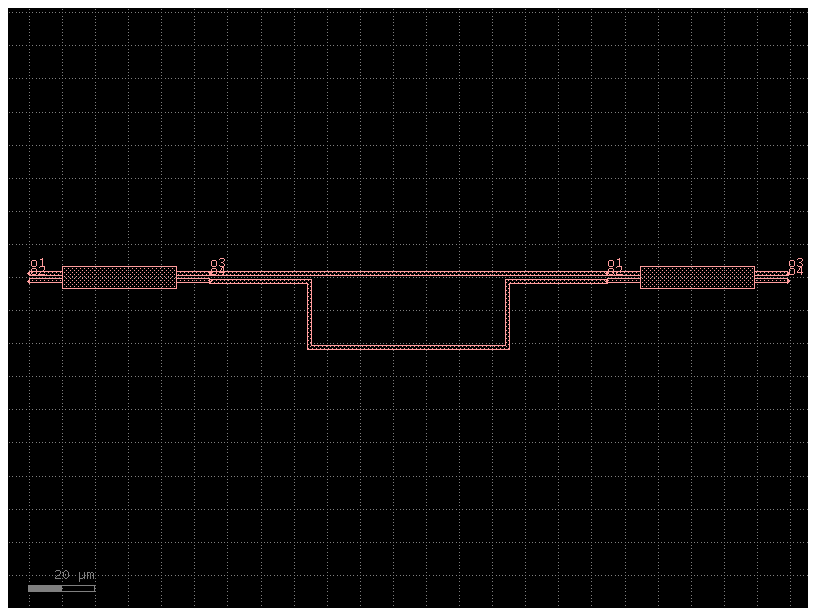

In [24]:
@gf.cell
def unbalanced_mzi_cell(w_wg=1.2,w_mmi=6.6,l_mmi=69.03598/2,l_wg=10.0,arm_length=120.0,delta_L=40.0,layer_wg="WG",):
    c = gf.Component()
    xs = gf.cross_section.strip(width=w_wg, layer=layer_wg)

    mmi1 = c.add_ref(mmi_cell(w_wg=w_wg,w_mmi=w_mmi,l_mmi=l_mmi,l_wg=l_wg,layer_wg=layer_wg,))
    mmi2 = c.add_ref(mmi_cell(w_wg=w_wg,w_mmi=w_mmi,l_mmi=l_mmi,l_wg=l_wg,layer_wg=layer_wg,))
    mmi2.dmovex(l_mmi + 2*l_wg + arm_length)

    x_start = mmi1.ports["o3"].dx
    x_end = mmi2.ports["o1"].dx

    y_top = mmi1.ports["o3"].dy
    y_bot = mmi1.ports["o4"].dy

    path_top = gf.Path([(x_start, y_top),(x_end, y_top),])
    wg_top = c.add_ref(gf.path.extrude(path_top,cross_section=xs,))

    h = delta_L / 2

    path_bottom = gf.Path([(x_start, y_bot),(x_start + arm_length/4, y_bot),(x_start + arm_length/4, y_bot - h),
            (x_end - arm_length/4, y_bot - h),
            (x_end - arm_length/4, y_bot),
            (x_end, y_bot),])
    wg_bottom = c.add_ref(gf.path.extrude(path_bottom,cross_section=xs,))


    c.add_port("in1", port=mmi1.ports["o1"])
    c.add_port("in2", port=mmi1.ports["o2"])
    c.add_port("out1", port=mmi2.ports["o3"])
    c.add_port("out2", port=mmi2.ports["o4"])

    return c

mzi_unbalanced = unbalanced_mzi_cell(delta_L=40.0)
mzi_unbalanced.plot()
mzi_unbalanced.show()

### 4.a.2. Cell of Unbalanced MZI using 2x2 50:50 MMIs with Thermal Tunners on top

2026-06-10 09:11:42.041 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


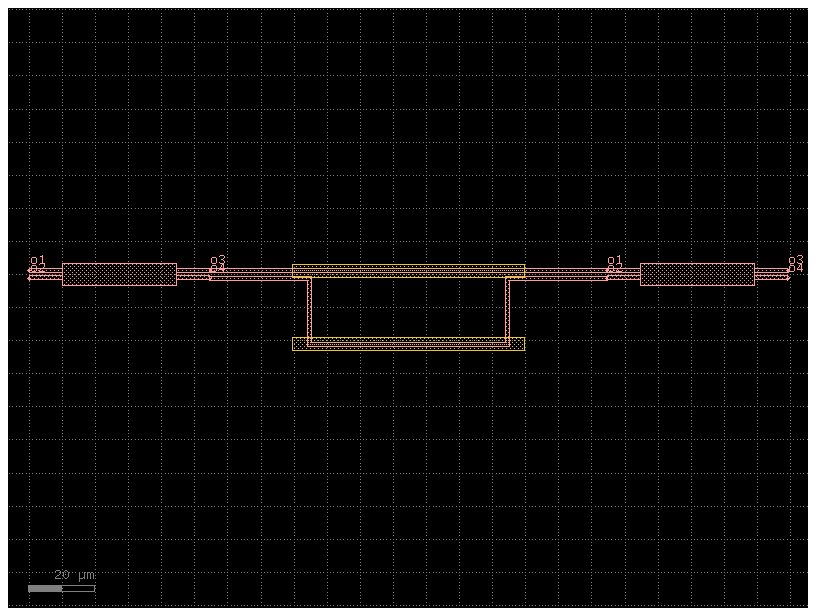

In [25]:
@gf.cell
def mzi_with_thermal_tuners_cell(
    w_wg=1.2,
    w_mmi=6.6,
    l_mmi=69.03598/2,
    l_wg=10.0,
    arm_length=120.0,
    delta_L=40.0,
    heater_width=4.0,
    heater_length=70.0,
    heater_offset=0.0,
    layer_wg="WG",
    layer_heater="HEATER",
):
    c = gf.Component()
    xs = gf.cross_section.strip(width=w_wg, layer=layer_wg)

    mmi1 = c.add_ref(mmi_cell(w_wg=w_wg,w_mmi=w_mmi,l_mmi=l_mmi,l_wg=l_wg,layer_wg=layer_wg,))
    mmi2 = c.add_ref(mmi_cell(w_wg=w_wg,w_mmi=w_mmi,l_mmi=l_mmi,l_wg=l_wg,layer_wg=layer_wg,))
    mmi2.dmovex(l_mmi + 2*l_wg + arm_length)

    x_start = mmi1.ports["o3"].dx
    x_end = mmi2.ports["o1"].dx

    y_top = mmi1.ports["o3"].dy
    y_bot = mmi1.ports["o4"].dy


    path_top = gf.Path([(x_start, y_top),(x_end, y_top),])
    wg_top = c.add_ref(gf.path.extrude(path_top,cross_section=xs,))


    h = delta_L / 2
    path_bottom = gf.Path([
            (x_start, y_bot),
            (x_start + arm_length/4, y_bot),
            (x_start + arm_length/4, y_bot - h),
            (x_end - arm_length/4, y_bot - h),
            (x_end - arm_length/4, y_bot),
            (x_end, y_bot),
        ])
    wg_bottom = c.add_ref(gf.path.extrude(path_bottom,cross_section=xs,))

    heater_top = c.add_ref(
        gf.components.rectangle(
            size=(heater_length, heater_width),
            layer=layer_heater,
        )
    )

    heater_bottom = c.add_ref(
        gf.components.rectangle(
            size=(heater_length, heater_width),
            layer=layer_heater,
        )
    )

    heater_x = (x_start + x_end) / 2 - heater_length / 2

    heater_top.dmovex(heater_x)
    heater_top.dmovey(y_top - heater_width/2 + heater_offset)

    y_lower_heater = y_bot - h
    heater_bottom.dmovex(heater_x)
    heater_bottom.dmovey(y_lower_heater - heater_width/2 + heater_offset)

    c.add_port("in1", port=mmi1.ports["o1"])
    c.add_port("in2", port=mmi1.ports["o2"])
    c.add_port("out1", port=mmi2.ports["o3"])
    c.add_port("out2", port=mmi2.ports["o4"])

    return c


mzi_tuners = mzi_with_thermal_tuners_cell(delta_L=40.0)
mzi_tuners.plot()
mzi_tuners.show()

### 4.a.3. Cell of all-pass Ring Resonator using 2x2 50:50

2026-06-10 09:11:42.475 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


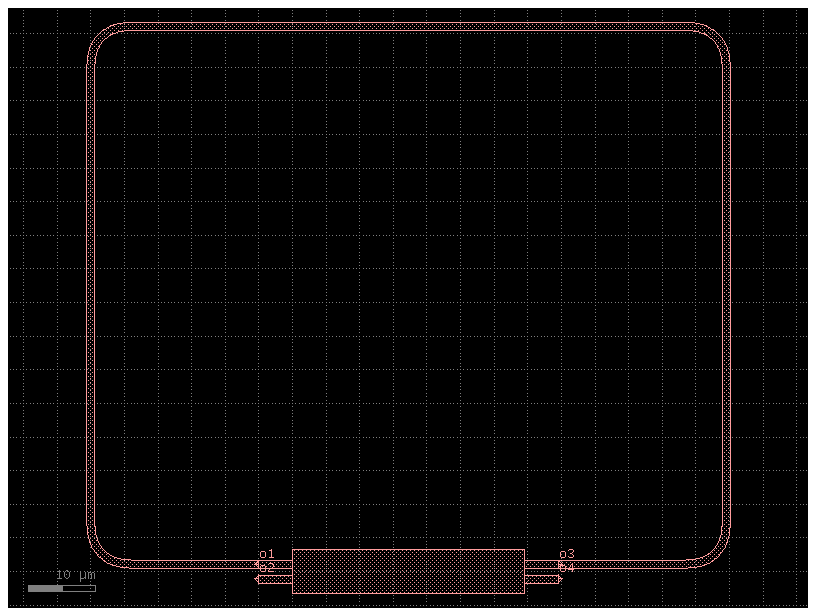

In [26]:
@gf.cell
def all_pass_ring_mmi_cell_curved(
    w_wg=1.2,
    w_mmi=6.6,
    l_mmi=69.03598/2,
    l_wg=5.0,
    ring_height=70.0,
    side_extension=25.0,
    extra_length=0.0,
    bend_radius=5.0,
    layer_wg="WG",
):
    c = gf.Component()

    xs = gf.cross_section.strip(width=w_wg, layer=layer_wg)

    # MMI 2x2 coupler
    mmi_ref = c.add_ref(
        mmi_cell(
            w_wg=w_wg,
            w_mmi=w_mmi,
            l_mmi=l_mmi,
            l_wg=l_wg,
            layer_wg=layer_wg,
        )
    )

    p_left = mmi_ref.ports["o1"]
    p_right = mmi_ref.ports["o3"]

    xL = p_left.dx
    yL = p_left.dy

    xR = p_right.dx
    yR = p_right.dy

    y_top = max(yL, yR) + ring_height + extra_length / 2

    points = [
        (xL, yL),
        (xL - side_extension, yL),
        (xL - side_extension, y_top),
        (xR + side_extension, y_top),
        (xR + side_extension, yR),
        (xR, yR),
    ]

    ring_path = gf.path.smooth(
        points=points,
        radius=bend_radius,
    )

    ring_wg = gf.path.extrude(
        ring_path,
        cross_section=xs,
    )

    c.add_ref(ring_wg)

    c.add_port("in", port=mmi_ref.ports["o2"])
    c.add_port("out", port=mmi_ref.ports["o4"])

    return c


ring_all_pass = all_pass_ring_mmi_cell_curved(
    ring_height=70.0,
    side_extension=25.0,
    extra_length=20.0,
    bend_radius=5.0,
)

ring_all_pass.plot()
ring_all_pass.show()

### 4.a.4. Cell of all-pass Ring Resonator using 2x2 50:50 with Thermal Tunners on top

2026-06-10 09:11:43.205 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


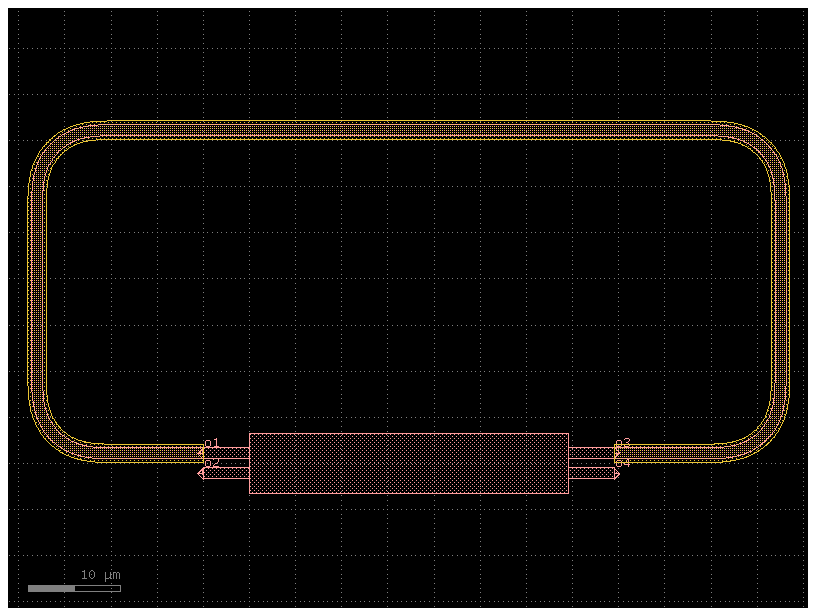

In [28]:
@gf.cell
def ring_with_perimeter_thermal_tuner_cell(
    w_wg=1.2,
    w_mmi=6.6,
    l_mmi=69.03598/2,
    l_wg=5.0,
    ring_height=35.0,
    side_extension=18.0,
    extra_length=0.0,
    bend_radius=6.0,
    heater_width=2.0,
    layer_wg="WG",
    layer_heater="HEATER",
):
    c = gf.Component()

    xs_wg = gf.cross_section.strip(width=w_wg, layer=layer_wg)
    xs_heater = gf.cross_section.strip(width=heater_width, layer=layer_heater)

    # MMI 2x2 coupler
    mmi_ref = c.add_ref(
        mmi_cell(
            w_wg=w_wg,
            w_mmi=w_mmi,
            l_mmi=l_mmi,
            l_wg=l_wg,
            layer_wg=layer_wg,
        )
    )

    p_left = mmi_ref.ports["o1"]
    p_right = mmi_ref.ports["o3"]

    xL = p_left.dx
    yL = p_left.dy

    xR = p_right.dx
    yR = p_right.dy

    y_top = max(yL, yR) + ring_height + extra_length / 2

    points = [
        (xL, yL),
        (xL - side_extension, yL),
        (xL - side_extension, y_top),
        (xR + side_extension, y_top),
        (xR + side_extension, yR),
        (xR, yR),
    ]

    # Ring waveguide path
    ring_path = gf.path.smooth(
        points=points,
        radius=bend_radius,
    )

    # Optical ring
    ring_wg = gf.path.extrude(
        ring_path,
        cross_section=xs_wg,
    )
    c.add_ref(ring_wg)

    # Thermal tuner following the same perimeter
    heater = gf.path.extrude(
        ring_path,
        cross_section=xs_heater,
    )
    c.add_ref(heater)

    c.add_port("in", port=mmi_ref.ports["o2"])
    c.add_port("out", port=mmi_ref.ports["o4"])

    return c


ring_tuned = ring_with_perimeter_thermal_tuner_cell(
    ring_height=35.0,
    side_extension=18.0,
    bend_radius=6.0,
    heater_width=2.0,
)

ring_tuned.plot()
ring_tuned.show()

### 4.a.5. Cell of an existing GDSfactory spiral components

2026-06-10 09:11:43.792 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


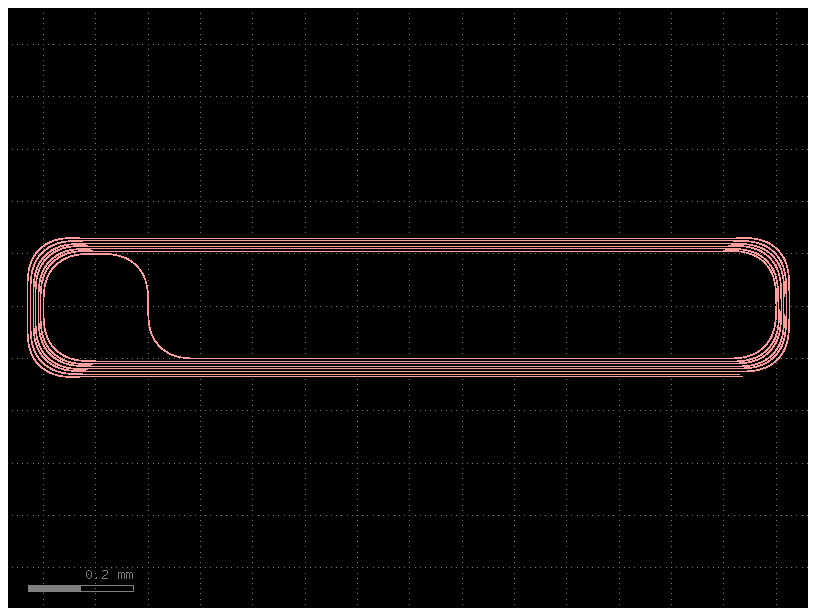

In [29]:
@gf.cell
def spiral_cell(
    length=1000.0,
    spacing=5.0,
    w_wg=1.2,
    layer_wg="WG",
):
    c = gf.Component()

    xs = gf.cross_section.strip(
        width=w_wg,
        layer=layer_wg,
    )

    # GDSFactory spiral component
    spiral = c.add_ref(
        gf.components.spiral(
            length=length,
            spacing=spacing,
            cross_section=xs,
        )
    )

    c.add_port("in", port=spiral.ports["o1"])
    c.add_port("out", port=spiral.ports["o2"])

    return c

spiral_test = spiral_cell(
    length=1000.0,
    spacing=5.0,
)

spiral_test.plot()
spiral_test.show()

### 4.b.1. Die with W = 5mm x L = 10mm

2026-06-10 09:11:44.123 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


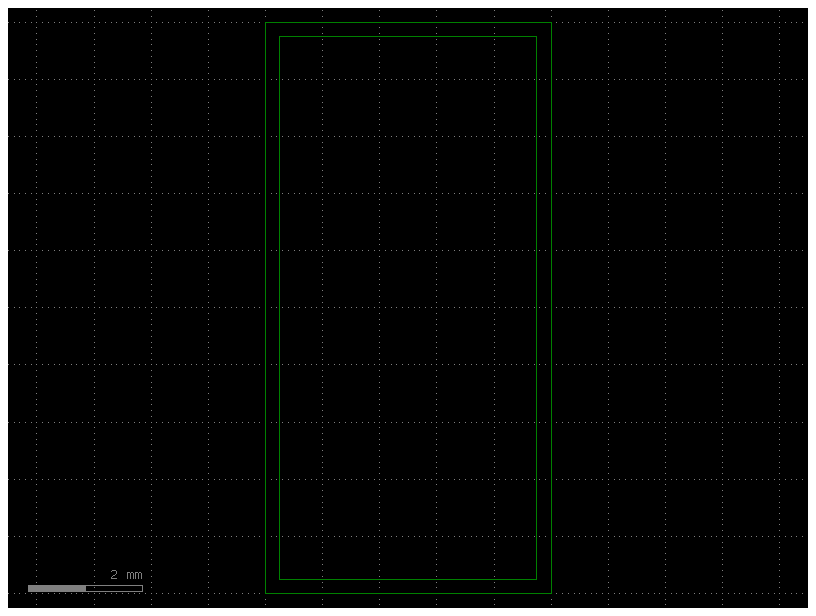

In [30]:
@gf.cell
def die_5x10mm_cell(
    dieW=5000.0,       # 5 mm = 5000 um
    dieL=10000.0,      # 10 mm = 10000 um
    border=250.0,
    layer_box="FLOORPLAN",
):
    c = gf.Component()

    outer = c.add_ref(
        gf.components.rectangle(
            size=(dieW, dieL),
            layer=layer_box,
        )
    )

    inner = c.add_ref(
        gf.components.rectangle(
            size=(dieW - 2*border, dieL - 2*border),
            layer=layer_box,
        )
    )

    inner.dmovex(border)
    inner.dmovey(border)

    die_outline = gf.boolean(
        A=outer,
        B=inner,
        operation="A-B",
        layer=layer_box,
    )

    c.add_ref(die_outline)
    
    c.add_port(
        name="block@org",
        center=(border, border),
        width=1,
        orientation=0,
        layer=layer_box,
    )

    return c

die_test = die_5x10mm_cell()
die_test.plot()
die_test.show()

### 4.b.2. Array of I/Os spaced at 250um

2026-06-10 09:11:44.609 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


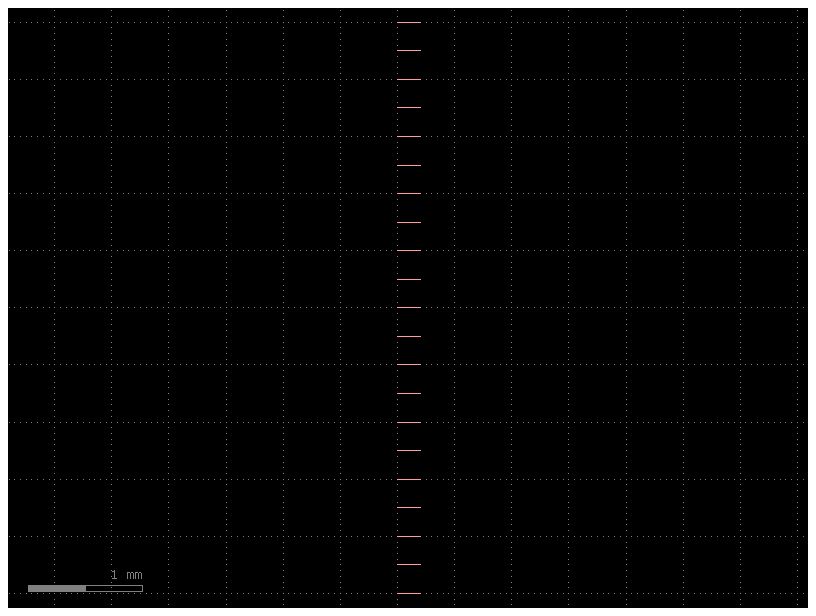

In [31]:
@gf.cell
def io_array_cell(
    dieW=5000.0,          # width available [um]
    io_spacing=250.0,     # spacing between I/Os [um]
    io_length=200.0,      # length of each I/O waveguide [um]
    io_width=1.2,         # same width as optical waveguides [um]
    layer_wg="WG",
):
    c = gf.Component()

    xs = gf.cross_section.strip(
        width=io_width,
        layer=layer_wg,
    )

    n_ios = int(dieW / io_spacing) + 1

    for i in range(n_ios):

        y = i * io_spacing

        io = c.add_ref(
            gf.components.straight(
                length=io_length,
                cross_section=xs,
            )
        )

        io.dmovey(y)

        c.add_port(
            name=f"io_{i}",
            port=io.ports["o2"],
        )

    return c

io_array = io_array_cell()
io_array.plot()
io_array.show()

### 4.b.3. Cell of this die with I/Os accesible to connect

2026-06-10 09:11:45.027 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


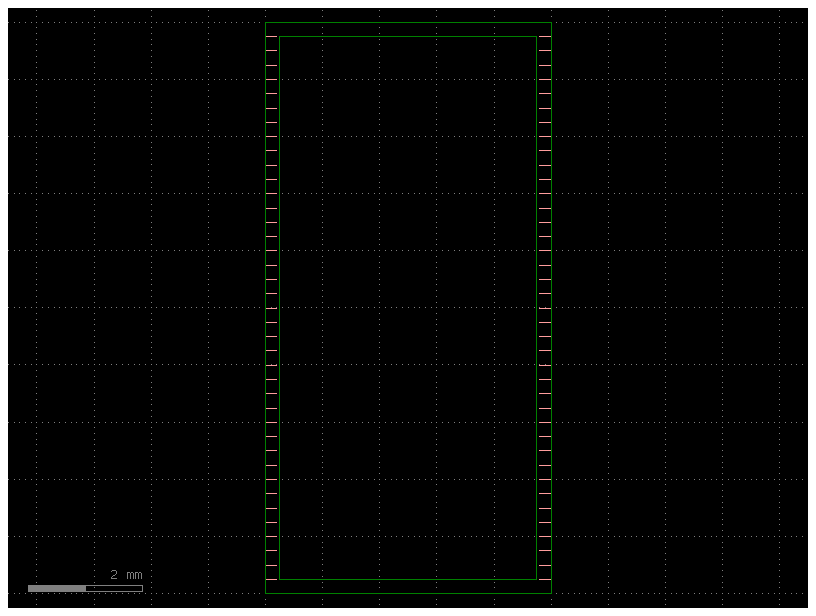

In [32]:
@gf.cell
def die_with_accessible_ios_cell(
    dieW=5000.0,          # 5 mm
    dieL=10000.0,         # 10 mm
    border=250.0,
    io_spacing=250.0,
    io_length=200.0,
    io_width=1.2,
    layer_wg="WG",
    layer_box="FLOORPLAN",
):
    c = gf.Component()

    outer = c.add_ref(
        gf.components.rectangle(
            size=(dieW, dieL),
            layer=layer_box,
        )
    )

    inner = c.add_ref(
        gf.components.rectangle(
            size=(dieW - 2 * border, dieL - 2 * border),
            layer=layer_box,
        )
    )

    inner.dmovex(border)
    inner.dmovey(border)

    die_outline = gf.boolean(
        A=outer,
        B=inner,
        operation="A-B",
        layer=layer_box,
    )

    c.add_ref(die_outline)

    xs = gf.cross_section.strip(
        width=io_width,
        layer=layer_wg,
    )

    y_start = border
    y_end = dieL - border

    n_ios = int((y_end - y_start) / io_spacing) + 1

    for i in range(n_ios):

        y = y_start + i * io_spacing

        # Left I/O
        io_left = c.add_ref(
            gf.components.straight(
                length=io_length,
                cross_section=xs,
            )
        )

        io_left.dmovex(0)
        io_left.dmovey(y)

        # Right I/O
        io_right = c.add_ref(
            gf.components.straight(
                length=io_length,
                cross_section=xs,
            )
        )

        io_right.dmovex(dieW - io_length)
        io_right.dmovey(y)

        # Accessible ports facing inside the die
        c.add_port(
            name=f"L{i}",
            port=io_left.ports["o2"],
        )

        c.add_port(
            name=f"R{i}",
            port=io_right.ports["o1"],
        )

    # Reference placement port
    c.add_port(
        name="block@org",
        center=(border, border),
        width=1,
        orientation=0,
        layer=layer_box,
    )

    return c


die_ios = die_with_accessible_ios_cell()
die_ios.plot()
die_ios.show()

### 4.c. Floorplaning and die layout

2026-06-10 09:11:45.816 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


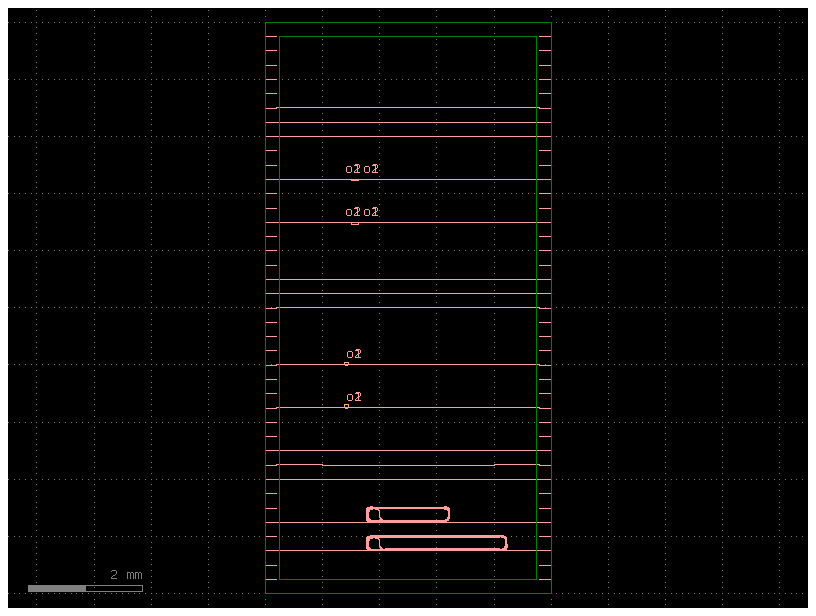

In [33]:
main_layout = gf.Component()

die_ref = main_layout.add_ref(
    die_with_accessible_ios_cell(
        dieW=5000.0,
        dieL=10000.0,
        border=250.0,
        io_spacing=250.0,
        io_length=200.0,
        io_width=1.2,
    )
)

xs = gf.cross_section.strip(width=1.2, layer="WG")

def io_y(index):
    return 250.0 + index * 250.0


def move_port_to_y(ref, port_name, target_y):
    dy = target_y - ref.ports[port_name].dy
    ref.dmovey(dy)


def route_ports_manual(component, port1, port2, x_mid=None, xs=xs):
    """
    Robust manual route between two ports.
    It does not depend on port orientation.
    """
    x1, y1 = port1.dx, port1.dy
    x2, y2 = port2.dx, port2.dy

    if x_mid is None:
        x_mid = (x1 + x2) / 2

    path = gf.Path(
        [
            (x1, y1),
            (x_mid, y1),
            (x_mid, y2),
            (x2, y2),
        ]
    )

    wg = gf.path.extrude(path, cross_section=xs)
    component.add_ref(wg)

straight_length = 3000.0
x_straight = 1000.0

straight_indices = [31, 32, 33, 19, 20, 21, 7, 8, 9]

for idx in straight_indices:

    y = io_y(idx)

    wg = main_layout.add_ref(
        gf.components.straight(
            length=straight_length,
            cross_section=xs,
        )
    )

    wg.dmovex(x_straight)
    wg.dmovey(y)

    route_ports_manual(
        component=main_layout,
        port1=die_ref.ports[f"L{idx}"],
        port2=wg.ports["o1"],
        xs=xs,
    )

    route_ports_manual(
        component=main_layout,
        port1=wg.ports["o2"],
        port2=die_ref.ports[f"R{idx}"],
        xs=xs,
    )

mzi_1 = main_layout.add_ref(
    unbalanced_mzi_cell(
        delta_L=40.0,
        arm_length=250.0,
    )
)

mzi_1.dmovex(1400.0)
move_port_to_y(mzi_1, "in1", io_y(28))

route_ports_manual(
    component=main_layout,
    port1=die_ref.ports["L28"],
    port2=mzi_1.ports["in1"],
    xs=xs,
)

route_ports_manual(
    component=main_layout,
    port1=mzi_1.ports["out1"],
    port2=die_ref.ports["R28"],
    xs=xs,
)


mzi_2 = main_layout.add_ref(
    unbalanced_mzi_cell(
        delta_L=80.0,
        arm_length=250.0,
    )
)

mzi_2.dmovex(1400.0)
move_port_to_y(mzi_2, "in1", io_y(25))

route_ports_manual(
    component=main_layout,
    port1=die_ref.ports["L25"],
    port2=mzi_2.ports["in1"],
    xs=xs,
)

route_ports_manual(
    component=main_layout,
    port1=mzi_2.ports["out1"],
    port2=die_ref.ports["R25"],
    xs=xs,
)

ring_1 = main_layout.add_ref(
    ring_with_top_thermal_tuner_cell(
        extra_length=0.0,
        ring_height=35.0,
    )
)

ring_1.dmovex(1400.0)
move_port_to_y(ring_1, "in", io_y(15))

route_ports_manual(
    component=main_layout,
    port1=die_ref.ports["L15"],
    port2=ring_1.ports["in"],
    xs=xs,
)

route_ports_manual(
    component=main_layout,
    port1=ring_1.ports["out"],
    port2=die_ref.ports["R15"],
    xs=xs,
)

ring_2 = main_layout.add_ref(
    ring_with_top_thermal_tuner_cell(
        extra_length=40.0,
        ring_height=35.0,
    )
)

ring_2.dmovex(1400.0)
move_port_to_y(ring_2, "in", io_y(12))

route_ports_manual(
    component=main_layout,
    port1=die_ref.ports["L12"],
    port2=ring_2.ports["in"],
    xs=xs,
)

route_ports_manual(
    component=main_layout,
    port1=ring_2.ports["out"],
    port2=die_ref.ports["R12"],
    xs=xs,
)

spiral_1 = main_layout.add_ref(
    spiral_cell(
        length=1000.0,
        spacing=5.0,
    )
)

spiral_1.dmovex(2100.0)
move_port_to_y(spiral_1, "in", io_y(4))

route_ports_manual(
    component=main_layout,
    port1=die_ref.ports["L4"],
    port2=spiral_1.ports["in"],
    xs=xs,
)

route_ports_manual(
    component=main_layout,
    port1=spiral_1.ports["out"],
    port2=die_ref.ports["R4"],
    xs=xs,
)


spiral_2 = main_layout.add_ref(
    spiral_cell(
        length=2000.0,
        spacing=5.0,
    )
)

spiral_2.dmovex(2100.0)
move_port_to_y(spiral_2, "in", io_y(2))

route_ports_manual(
    component=main_layout,
    port1=die_ref.ports["L2"],
    port2=spiral_2.ports["in"],
    xs=xs,
)

route_ports_manual(
    component=main_layout,
    port1=spiral_2.ports["out"],
    port2=die_ref.ports["R2"],
    xs=xs,
)

main_layout.plot()
main_layout.show()